In [1]:
import pandas as pd
import plotly.express as px

df = px.data.gapminder()

print(f"Loaded: {len(df)} rows")
print(df.head())

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-nu

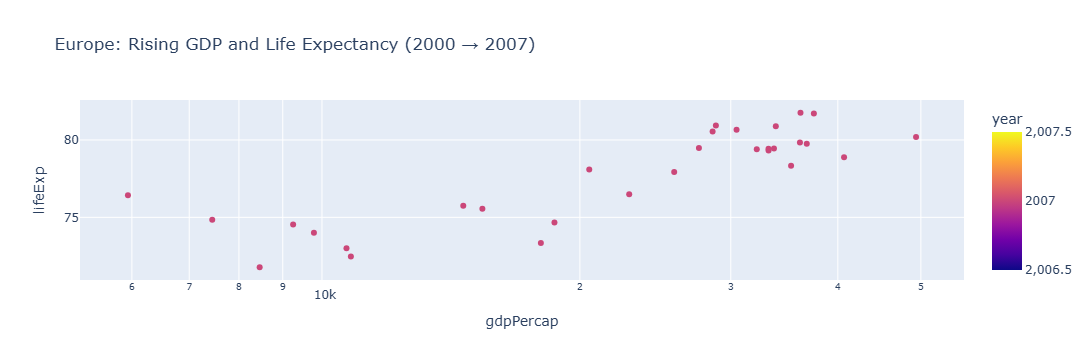

In [2]:
# Task 1 — Europe 2000 vs 2007

df_task1 = df[
    (df["continent"] == "Europe") &
    (df["year"].isin([2000, 2007]))
]

fig1 = px.scatter(
    df_task1,
    x="gdpPercap",
    y="lifeExp",
    color="year",
    hover_name="country",
    log_x=True,
    title="Europe: Rising GDP and Life Expectancy (2000 → 2007)",
    color_discrete_sequence=["#1f77b4", "#d62728"]
)

fig1.show()

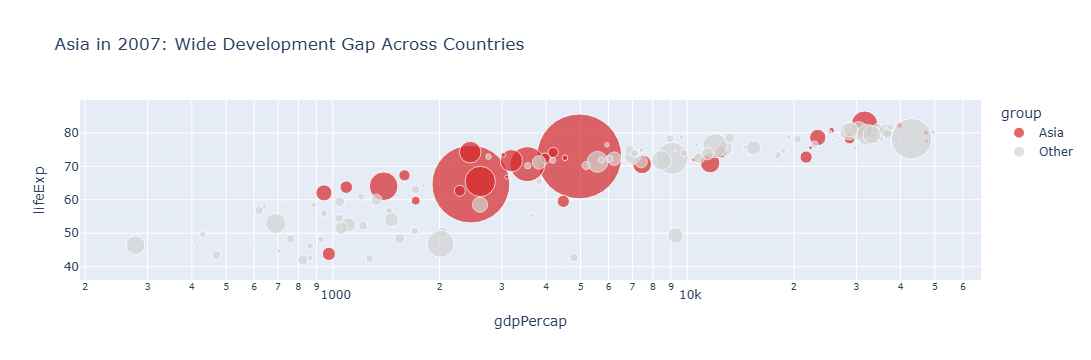

In [7]:
# Task 2 — Bubble Chart (Asia highlight)
df_2007 = df[df["year"] == 2007].copy()

df_2007["group"] = df_2007["continent"].apply(
    lambda x: "Asia" if x == "Asia" else "Other"
)

fig2 = px.scatter(
    df_2007,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="group",
    hover_name="country",
    log_x=True,
    size_max=60,
    title="Asia in 2007: Wide Development Gap Across Countries",
    color_discrete_map={
        "Asia": "#d62728",
        "Other": "lightgrey"
    }
)

fig2.add_annotation(
    x=4000,
    y=72,
    text="Asia shows strong diversity:\nfrom low-income countries\nto high-income economies (Japan, Singapore)",
    showarrow=True,
    arrowhead=1
)

fig2.show()